<a href="https://colab.research.google.com/github/sgruyzcki/DiploDatos2026/blob/main/Entregable_P1_Mariano.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import io
import math
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_context('talk')

# Ejercicio 1 - Análisis descriptivo

Responder a la pregunta: **¿Cuáles son los lenguajes de programación asociados a los mejores salarios?**

Para ello:
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en una sub-población. Por ejemplo, se pueden limitar a personas con un salario mayor que 300000 pesos, o a las personas que trabajan sólo en "Data Science", pero deben justificar su elección y reformular la pregunta inicial de ser necesario.
  * Obtener una lista de los lenguajes de programación más populares. Decidir cuántos y cuáles seleccionan para incluir en el análisis.
  * Para cada una de las otras columnas del punto anterior, elegir los rangos o valores seleccionan para incluir en el análisis.
3. Seleccionar métricas que ayuden a responder la pregunta, y los métodos para analizarlas. Elegir UNA de las siguientes opciones:
  * Comparar las distribuciones de salario para cada lenguaje utilizando visualizaciones. Como la visualización es el producto final, debe ser clara y mostrar información relevante.
  * Comparar medidas de estadística descriptiva sobre la distribución de salario para cada lenguaje. Sean creativos, la estadística descriptiva nos permite decir cosas como: "el 10% de los mejores sueldos los ganan, en su mayoría, programadores que saben kotlin!" (donde *mayoría* es un término medio engañoso que sólo significa más del 50%). Para comparar múltiples lenguajes, les recomendamos usar también visualizaciones.
  * Comparar probabilidades. Por ejemplo: "Si sabés Python o Java, tenés un 30% más de chances de ganar arriba de 1000K".

Si lo consideran necesario, realicen varias iteraciones. Es decir, si encuentran que las distribuciones de los lenguajes de programación que seleccionaron inicialmente no son muy diferentes, pueden re-hacer el análisis usando sólo los lenguajes de programación que son diferentes.

## Lectura del dataset

In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/master/sysarmy_survey_2026_processed.csv'
df_raw = pd.read_csv(url)
df_raw.head(3)

,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,salary_inflation_adjustment,...,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,salir_o_seguir_contestando_sobre_estudios,profile_age,profile_gender,profile_previous_survey,company_best_companies,sueldo_dolarizado,work_seniority,_sal
0,Mendoza,Full-Time,Staff (planta permanente),3000000.0,2400000.0,Mi sueldo está dolarizado (pero cobro en moned...,1300,No,Performance individual,No,...,NaN,NaN,NaN,45,Mujer Cis,Sí,NaN,True,Senior,3000000.0
1,Santa Fe,Full-Time,Contractor,5000000.0,5000000.0,Cobro todo el salario en dólares,1400,No,No recibo bono,No,...,NaN,NaN,NaN,50,Mujer Cis,Sí,NaN,True,Senior,5000000.0
2,Buenos Aires,Full-Time,Tercerizado (trabajo a través de consultora o ...,4600000.0,3600000.0,Cobro parte del salario en dólares,1436,No,No recibo bono,Uno,...,0.0,Porcentaje de mi sueldo bruto,Terminar encuesta,36,Mujer Cis,Sí,NaN,True,Senior,4600000.0


In [3]:
# Columnas a utilizar en el analisis
relevant_columns = ['tools_programming_languages', 'salary_monthly_NETO',
                    'work_dedication', 'work_seniority', 'company_main_activity']

In [4]:
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4938 non-null   object 
 1   salary_monthly_NETO          4717 non-null   float64
 2   work_dedication              4939 non-null   object 
 3   work_seniority               4939 non-null   object 
 4   company_main_activity        4939 non-null   object 
dtypes: float64(1), object(4)
memory usage: 193.1+ KB


In [5]:
# Limpieza sobre columnas relevantes
df_raw = df_raw.drop_duplicates()
df_raw = df_raw.dropna(subset=relevant_columns)
df_raw[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4715 entries, 0 to 4938
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4715 non-null   object 
 1   salary_monthly_NETO          4715 non-null   float64
 2   work_dedication              4715 non-null   object 
 3   work_seniority               4715 non-null   object 
 4   company_main_activity        4715 non-null   object 
dtypes: float64(1), object(4)
memory usage: 221.0+ KB


In [6]:
df_raw[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.715000e+03,4.715000e+03
mean,3.830842e+06,3.599654e+06
std,2.445617e+06,1.184002e+07
min,2.000000e+05,1.600000e+00
25%,2.146764e+06,1.851500e+06
50%,3.215000e+06,2.750000e+06
75%,4.885542e+06,4.000000e+06
max,2.000000e+07,6.533882e+08


In [7]:
# Fijo rango de salario neto: 300k - 30M
df_bounded = df_raw[(df_raw["salary_monthly_NETO"] >= 300_000) & (df_raw["salary_monthly_NETO"] <= 30_000_000)].copy()
df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].info()


<class 'pandas.core.frame.DataFrame'>
Index: 4669 entries, 0 to 4938
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   salary_monthly_BRUTO  4669 non-null   float64
 1   salary_monthly_NETO   4669 non-null   float64
dtypes: float64(2)
memory usage: 109.4 KB


(0.0, 20000000.0)

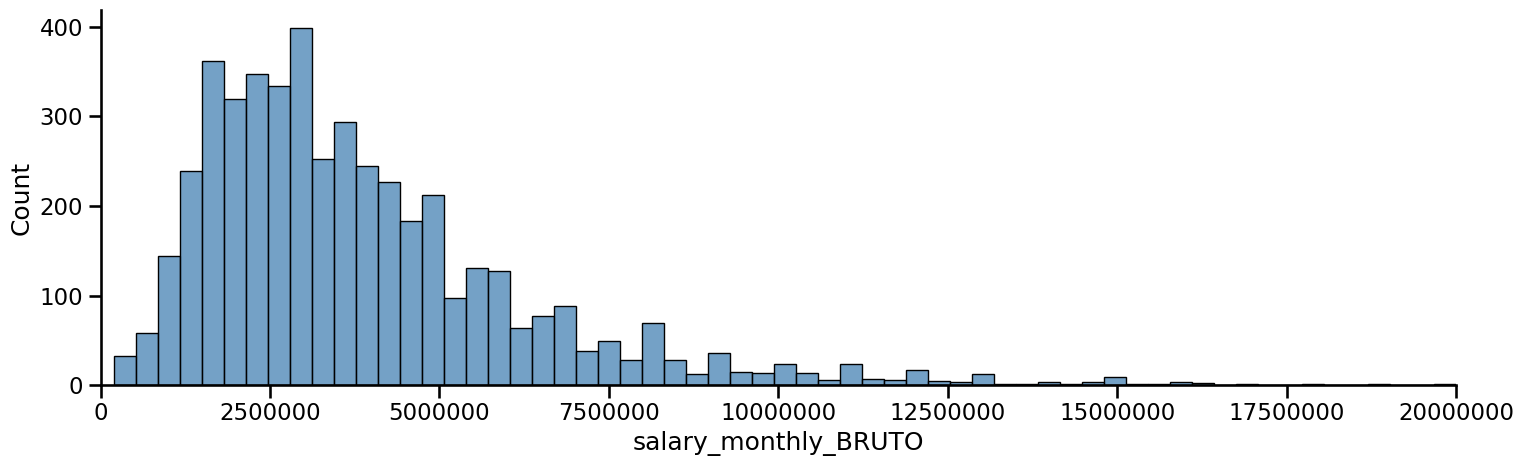

In [8]:
# Salario BRUTO
max_bruto = max(df_bounded["salary_monthly_BRUTO"])

sns.displot(df_bounded["salary_monthly_BRUTO"], aspect=3,color = "steelblue",edgecolor = "black",
             linewidth = 1)
plt.ticklabel_format(style='plain', axis='x')
plt.xlim((0,max_bruto))#100000000

(0.0, 30000000.0)

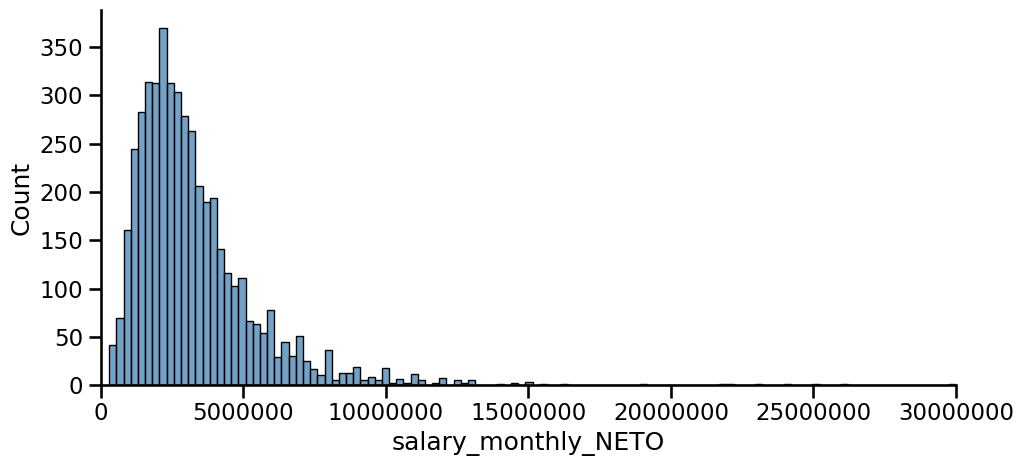

In [9]:
# Salario NETO
max_neto = max(df_bounded["salary_monthly_NETO"])

sns.displot(df_bounded["salary_monthly_NETO"], aspect=2,color = "steelblue",edgecolor = "black",
             linewidth = 1)
plt.ticklabel_format(style='plain', axis='x')
plt.xlim((0,max_neto))#100000000

In [10]:
# Verificación BRUTO > NETO
consistency = df_bounded.salary_monthly_BRUTO > df_bounded.salary_monthly_NETO

# Contar la cantidad de veces que se cumple la condición
count_true = consistency.sum()
count_false = (~consistency).sum()

print(f"Filas donde BRUTO > NETO: {count_true}")
print(f"Filas donde BRUTO <= NETO: {count_false}")

Filas donde BRUTO > NETO: 4002
Filas donde BRUTO <= NETO: 667


In [12]:
# Agregar flagger (booleano)
df_bounded['bruto_mayor_que_neto'] = consistency

# Eliminar filas con ratio > 1.5: Errores evidentes
df_bounded = df_bounded[
    df_bounded['salary_monthly_NETO'] / df_bounded['salary_monthly_BRUTO'] < 1.5]

df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.624000e+03,4.624000e+03
mean,3.863712e+06,3.234505e+06
std,2.436334e+06,2.035319e+06
min,3.000000e+05,3.000000e+05
25%,2.200000e+06,1.873046e+06
50%,3.270200e+06,2.750000e+06
75%,4.900000e+06,4.000000e+06
max,2.000000e+07,1.900000e+07


Tengo en este punto 622 casos con Bruto <= Neto sobre 4624 entradas (13.45%).

In [15]:
# Comparación entre salarios por empleo. Vale la pena segmentar?
df_bcopy = df_bounded.copy()

df_bcopy.groupby('company_main_activity')['salary_monthly_NETO'].describe()

# Ordenar la descripcion descendentemente en funcion de la mediana

df_bcopy.groupby('work_seniority')['salary_monthly_NETO'].describe().sort_values(by='50%', ascending=False).head(5)
df_bcopy.groupby('company_main_activity')['salary_monthly_NETO'].describe().sort_values(by='50%', ascending=False).head(5)

,count,mean,std,min,25%,50%,75%,max
company_main_activity,,,,,,,,
Expert,1.0,11268613.0,NaN,11268613.0,11268613.0,11268613.0,11268613.0,11268613.0
Investigación y desarrollo,1.0,6900000.0,NaN,6900000.0,6900000.0,6900000.0,6900000.0,6900000.0
SAP,1.0,6400000.0,NaN,6400000.0,6400000.0,6400000.0,6400000.0,6400000.0
una empresa chica hago de todo :-),1.0,5800000.0,NaN,5800000.0,5800000.0,5800000.0,5800000.0,5800000.0
Jefe tecnología it data Center,1.0,5299524.0,NaN,5299524.0,5299524.0,5299524.0,5299524.0,5299524.0


Se opta por no segmentar por actividad principal para evitar desestimar paquetes de tecnologias completos asociados a dichas areas en el analisis.

In [16]:
# Se considera la subpoblacion con dedicacion Full-Time
#194 Part-time; 4430 Full-time
df_bcopy.groupby("work_dedication")["salary_monthly_NETO"].describe()

# Eliminar filas con work_dedication Part time en un nuevo df restringido
df_restricted = df_bcopy.drop(df_bcopy[df_bcopy["work_dedication"] == "Part-Time"].index)
df_restricted["salary_monthly_NETO"].describe()

,salary_monthly_NETO
count,4.430000e+03
mean,3.291633e+06
std,2.036418e+06
min,3.000000e+05
25%,1.921332e+06
50%,2.800000e+06
75%,4.000000e+06
max,1.900000e+07


### Resumen de lo obtenido hasta aquí:

En este punto se tiene un data set libre de duplicados, nulos y outliers en las columnas de interés, con un rango salarial neto entre 300k y 30M, enfocado en dedicación Full-Time. Se identificaron los casos en que NETO >= BRUTO. Además, se admite la posibilidad de segmentar el estudio a seniorities específicas (Junior, Semi-senior y Senior). Se optó por no segmentar el estudio en función del puesto, a fin de incluir una diversidad de lenguajes mayor en el estudio.  

### Conteo de frecuencias de los lenguajes de programación

In [17]:
df_restricted.tools_programming_languages[:3]

,tools_programming_languages
0,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL"
1,".NET, C#, HTML, Javascript, SQL"
2,"Go, SQL"


In [18]:
# Separación de lenguajes como variables independientes

# Convert the comma-separated string of languages to a list of string.
# Remove 'ninguno de los anteriores' option, spaces and training commas.
def split_languages(languages_str):
  if not isinstance(languages_str, str):
    return []
  # Remove 'other' option
  languages_str = languages_str.lower()\
    .replace('ninguno de los anteriores', '')
  # Split string into list of items
  # Remove spaces and commas for each item
  return [lang.strip().replace(',', '')
          for lang in languages_str.split()]

# Create a new column with the list of languages
df_restricted.loc[:, 'cured_programming_languages'] = df_restricted.tools_programming_languages\
    .apply(split_languages)
if 'cured_programming_languages' not in relevant_columns:
    relevant_columns.append('cured_programming_languages')

# Duplicate each row of df for each programming language
# mentioned in the response.
# We only include in df_lang the columns we are going to analyze later, so we
# don't duplicate innecesary information.
df_lang = df_restricted.cured_programming_languages\
    .apply(pd.Series).stack()\
    .reset_index(level=-1, drop=True).to_frame()\
    .join(df_restricted[relevant_columns])\
    .rename(columns={0: 'programming_language'})
# Horrible programming style! But a lot of data science code can be written with
# as concatenations of functions (pipelines), and there's no elegant way of
# doing that on Python.
df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,work_dedication,work_seniority,company_main_activity,cured_programming_languages
0,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"


In [19]:
language_count = df_lang.programming_language.value_counts()\
    .reset_index()\
    .rename(columns={'index': 'language', 'programming_language': 'frequency'})
language_count[:16]

,frequency,count
0,sql,1999
1,javascript,1672
2,python,1579
3,html,1234
4,typescript,1030
5,bash/shell,796
6,css,781
7,java,720
8,php,493
9,.net,492


In [20]:
# Considero para el estudio los lenguajes con una cantidad superior a 100
# usuarios, para robustecer la estadística.

# Filter out languages that we want to exclude
# Complete here with your selected list.
interesting_languages = ["sql","javascript","python","html","typescript",
                         "bash/shell","css","java","php",".net","c#","go",
                         "kotlin","vba","c++"]
filtered_df_lang = df_lang[df_lang.programming_language.isin(interesting_languages)]
filtered_df_lang[:5]

,programming_language,tools_programming_languages,salary_monthly_NETO,work_dedication,work_seniority,company_main_activity,cured_programming_languages
0,.net,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,c#,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,css,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,go,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"
0,html,".NET, C#, CSS, Go, HTML, Java, Javascript, SQL",2400000.0,Full-Time,Senior,Developer,"[.net, c#, css, go, html, java, javascript, sql]"


In [21]:
filtered_df_lang.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11799 entries, 0 to 4938
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   programming_language         11799 non-null  object 
 1   tools_programming_languages  11799 non-null  object 
 2   salary_monthly_NETO          11799 non-null  float64
 3   work_dedication              11799 non-null  object 
 4   work_seniority               11799 non-null  object 
 5   company_main_activity        11799 non-null  object 
 6   cured_programming_languages  11799 non-null  object 
dtypes: float64(1), object(6)
memory usage: 737.4+ KB


In [22]:
# Uso de la mediana como estadística comparativa para mayor robustez.
filtered_df_lang.groupby("programming_language")["salary_monthly_NETO"].describe().sort_values(by="50%", ascending=False)

,count,mean,std,min,25%,50%,75%,max
programming_language,,,,,,,,
go,251.0,4.677371e+06,2.439641e+06,600000.00,3000000.00,4000000.0,5957094.5,13000000.0
kotlin,125.0,4.335585e+06,2.354289e+06,400000.00,2775880.00,3885000.0,5445799.0,15000000.0
c++,112.0,3.701843e+06,2.145915e+06,400000.00,1886835.00,3453559.5,5000000.0,11000000.0
java,720.0,3.647201e+06,2.016729e+06,389300.00,2248404.75,3200000.0,4600000.0,15000000.0
bash/shell,796.0,3.646157e+06,2.222634e+06,300000.00,2100000.00,3070000.0,4513750.0,16159000.0
typescript,1030.0,3.685266e+06,2.368666e+06,302000.00,2077410.25,3060000.0,4500000.0,15000000.0
python,1579.0,3.557006e+06,2.206432e+06,300000.00,2086711.00,3000000.0,4396028.0,19000000.0
javascript,1672.0,3.413801e+06,2.156690e+06,300000.00,1925500.00,2900354.5,4200000.0,15000000.0
c#,397.0,3.247758e+06,1.795325e+06,302000.00,2000000.00,2800000.0,4000000.0,10440000.0


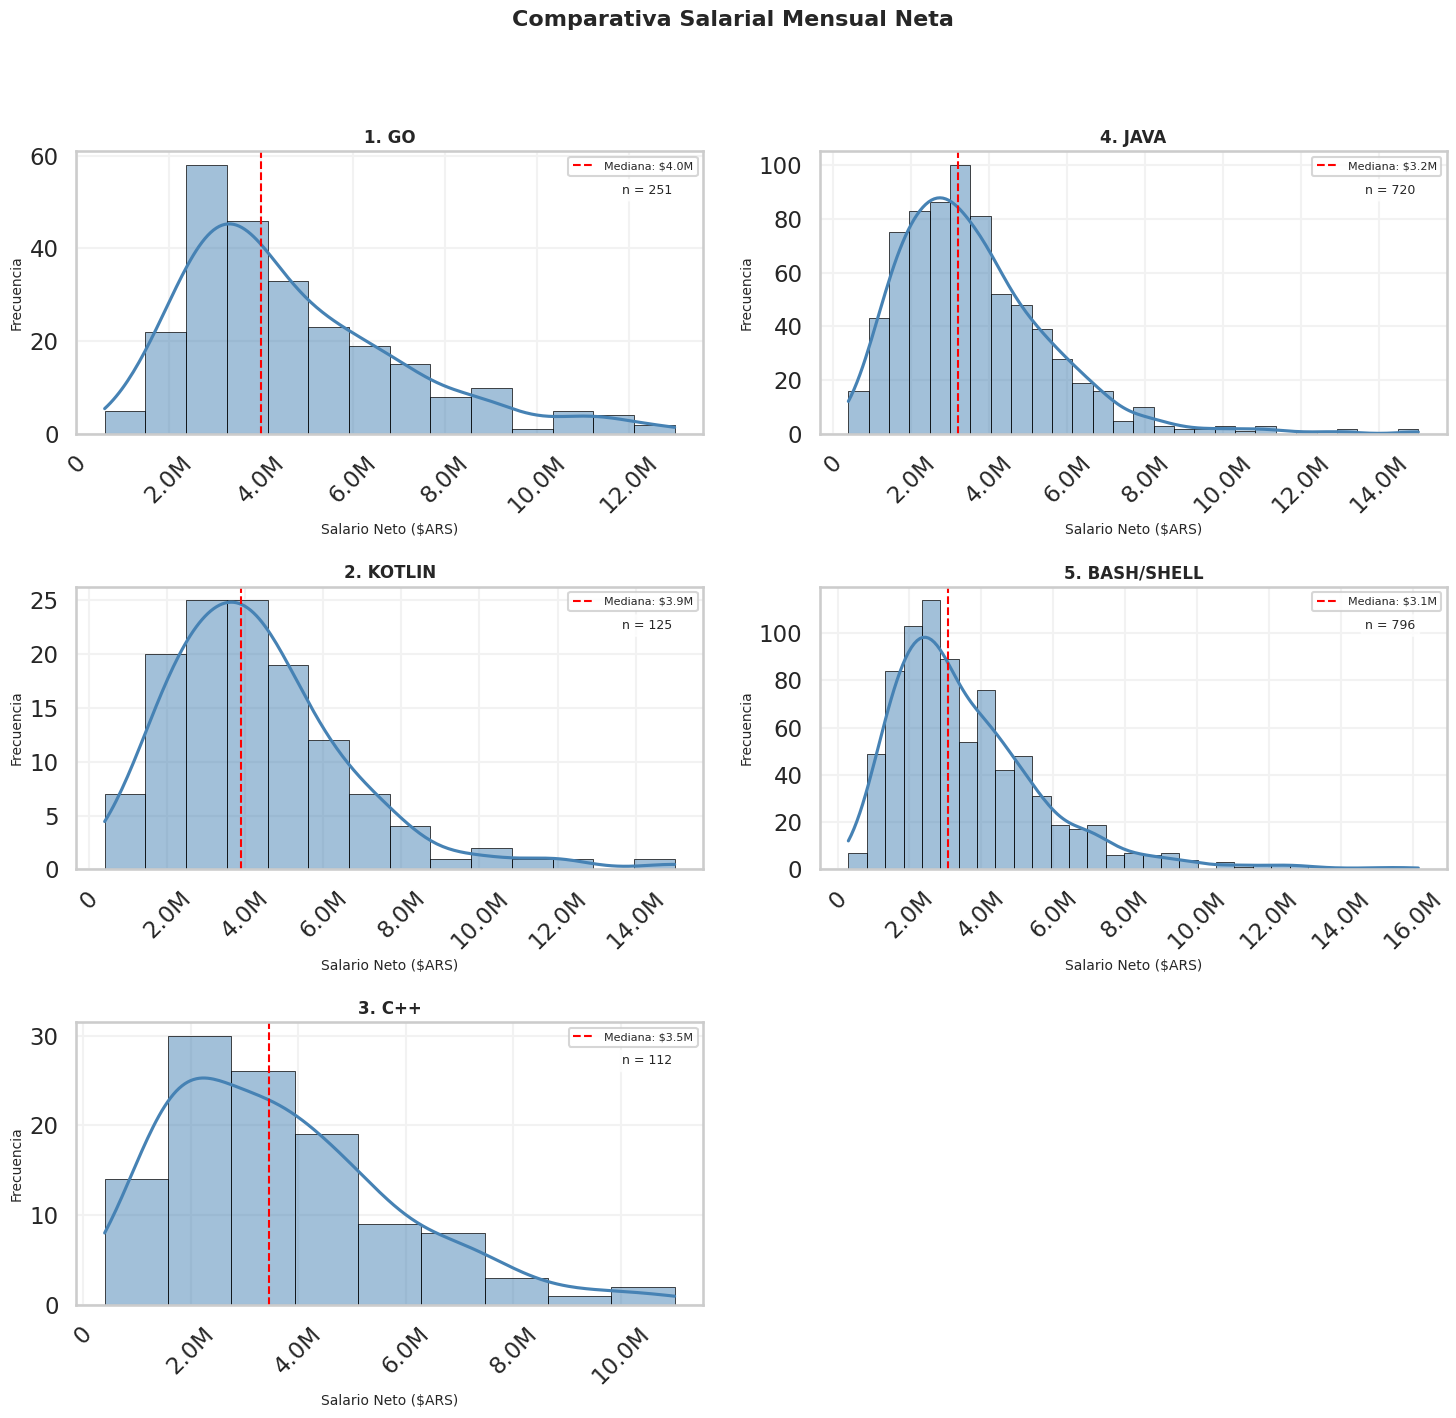

In [24]:
# Visualizacion comparativa de la distribucion salarial neta entre los 5
# lenguajes asociados a los mayores sueldos (por mediana).

# Identificacion del Top 5
top_5_languages = (
    filtered_df_lang.groupby('programming_language')['salary_monthly_NETO']
    .median()
    .sort_values(ascending=False)
    .head(5)
    .index.tolist()
)

# Configuracion de la matriz
rows, cols = 3, 2
fig, axes = plt.subplots(rows, cols, figsize=(15, 15))

# Llenado de la matriz por columnas
# .T transpone la matriz de ejes y .flatten() la aplana.
# Esto hace que el orden de los ejes en la lista sea:
# (0,0), (1,0), (2,0) -> Primera columna
# (0,1), (1,1), (2,1) -> Segunda columna
axes_flat = axes.T.flatten()

sns.set_style("whitegrid", {'axes.grid': True, 'grid.color': '.95'})

def salary_formatter_m(x, pos):
    millions = x * 1e-6
    return f'{millions:.1f}M' if x != 0 else '0'

# Iteraciones sobre la lista reordenada
for i, lang in enumerate(top_5_languages):
    ax = axes_flat[i]
    data_lang = filtered_df_lang[filtered_df_lang['programming_language'] == lang]['salary_monthly_NETO']

    sns.histplot(data_lang, kde=True, color='steelblue', edgecolor='black', linewidth=0.5, ax=ax)

    # Mediana
    median_val = data_lang.median()
    ax.axvline(median_val, color='red', linestyle='--', linewidth=1.5,
               label=f'Mediana: ${median_val*1e-6:.1f}M')

    # Formateo
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(salary_formatter_m))
    ax.tick_params(axis='x', rotation=45)

    ax.set_title(f'{i+1}. {lang.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Salario Neto ($ARS)', fontsize=10)
    ax.set_ylabel('Frecuencia', fontsize=10)

    ax.text(0.95, 0.85, f'n = {len(data_lang)}', transform=ax.transAxes,
            fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.7),
            horizontalalignment='right')
    ax.legend(fontsize=8)

# Eliminacion de ejes sobrantes
# Como tenemos 5 lenguajes y 6 espacios, el último de la segunda columna (axes_flat[5]) estará vacío
if len(top_5_languages) < len(axes_flat):
    for j in range(len(top_5_languages), len(axes_flat)):
        fig.delaxes(axes_flat[j])

plt.suptitle('Comparativa Salarial Mensual Neta', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [25]:
df_restricted[relevant_columns].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4430 entries, 0 to 4938
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tools_programming_languages  4430 non-null   object 
 1   salary_monthly_NETO          4430 non-null   float64
 2   work_dedication              4430 non-null   object 
 3   work_seniority               4430 non-null   object 
 4   company_main_activity        4430 non-null   object 
 5   cured_programming_languages  4430 non-null   object 
dtypes: float64(1), object(5)
memory usage: 371.3+ KB


Análisis válido sobre el 89.71% del total de datos originales. Segmentación: Programadores con dedicación Full-Time dentro de un rango de 300k-30M ARS.

# Ejercicio 2 - Densidades y varias variables

Responder a la pregunta general: **¿Que herramientas (prácticas y teóricas) són útiles para explorar la base, descubrir patrones, asociaciones?**

Para ello considere (igual al ejercicio Anterior):
1. Seleccionar las columnas relevantes para analizar.
2. Seleccionar las filas relevantes para analizar. Esto incluye la eliminación de valores extremos y erróneos, pero también puede enfocar el análisis en sub-poblaciones.

## a) Densidad conjunta

Que herramientas visuales y modelos puede utilizar para estudiar la distribución y comportamiento de sus datos?

Elija tres variables numéricas y 2 variables categóricas. Visualice la base según varias de las variables elegidas. Puede describir de alguna forma el comportamiento de sus datos? Que herramientas utilizaría? Describa




## b) Asociación

* Necesitamos decidir si sacar o no la columna de salario bruto. Para hacer la encuesta más simple.
¿Existe una correlación entre el salario bruto y el neto? Que abordaje y medidas usaría



## c) Densidad condicional

Estudie la distribución del salario según el nivel de estudio.

Separe la población según el nivel de estudio (elija dos subpoblaciones numerosas) y grafique de manera comparativa ambos histogramas de la variable `'salary_monthly_NETO'`
¿Considera que ambas variables son independientes?
¿Qué analizaría al respecto?

Calcule medidas de centralización y dispersión para cada subpoblación






## d) Densidad Conjunta condicional

Elija dos variables numéricas y una categórica.
Estudie la dispersión (scatterplot) de las dos variables discriminando en color por la variable categórica (ayuda: hue en seaborn)


In [26]:
# Selección de variables categóricas y numéricas

# Columnas a utilizar en el analisis
relevant_columns_two = ['salary_monthly_NETO','profile_years_experience', 'work_years_in_company',
                       'work_seniority', 'company_main_activity',
                        'work_dedication']

In [27]:
df_raw = pd.read_csv(url)
df_raw[relevant_columns_two].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4939 entries, 0 to 4938
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   salary_monthly_NETO       4717 non-null   float64
 1   profile_years_experience  4939 non-null   int64  
 2   work_years_in_company     4939 non-null   int64  
 3   work_seniority            4939 non-null   object 
 4   company_main_activity     4939 non-null   object 
 5   work_dedication           4939 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 231.6+ KB


In [33]:
# Limpieza sobre columnas relevantes
df_raw = df_raw.drop_duplicates()
df_raw = df_raw.dropna(subset=relevant_columns_two)
df_raw[relevant_columns_two].info()

<class 'pandas.core.frame.DataFrame'>
Index: 4716 entries, 0 to 4938
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   salary_monthly_NETO       4716 non-null   float64
 1   profile_years_experience  4716 non-null   int64  
 2   work_years_in_company     4716 non-null   int64  
 3   work_seniority            4716 non-null   object 
 4   company_main_activity     4716 non-null   object 
 5   work_dedication           4716 non-null   object 
dtypes: float64(1), int64(2), object(3)
memory usage: 257.9+ KB


In [34]:
# Fijo rango de salario neto: 300k - 30M
df_bounded = df_raw[(df_raw["salary_monthly_NETO"] >= 300_000) & (df_raw["salary_monthly_NETO"] <= 30_000_000)].copy()

In [35]:
df_bounded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4670 entries, 0 to 4938
Data columns (total 60 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4670 non-null   object 
 1   work_dedication                                       4670 non-null   object 
 2   work_contract_type                                    4670 non-null   object 
 3   salary_monthly_BRUTO                                  4670 non-null   float64
 4   salary_monthly_NETO                                   4670 non-null   float64
 5   salary_in_usd                                         1445 non-null   object 
 6   salary_last_dollar_value                              968 non-null    object 
 7   salary_has_bonus                                      4670 non-null   object 
 8   salary_bonus_tied_to                                  4669 non-

In [38]:
# Verificación BRUTO > NETO + boolean flag
consistency = df_bounded.salary_monthly_BRUTO >= df_bounded.salary_monthly_NETO
df_bounded['bruto_mayor_que_neto'] = consistency

# Eliminar filas con ratio > 1.5: Errores evidentes
df_bounded = df_bounded[
    df_bounded['salary_monthly_NETO'] / df_bounded['salary_monthly_BRUTO'] < 1.5]

df_bounded[["salary_monthly_BRUTO", "salary_monthly_NETO"]].describe()

,salary_monthly_BRUTO,salary_monthly_NETO
count,4.625000e+03,4.625000e+03
mean,3.863957e+06,3.234562e+06
std,2.436128e+06,2.035103e+06
min,3.000000e+05,3.000000e+05
25%,2.200000e+06,1.874062e+06
50%,3.270400e+06,2.750000e+06
75%,4.900000e+06,4.000000e+06
max,2.000000e+07,1.900000e+07


In [39]:
df_bounded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4625 entries, 0 to 4938
Data columns (total 61 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4625 non-null   object 
 1   work_dedication                                       4625 non-null   object 
 2   work_contract_type                                    4625 non-null   object 
 3   salary_monthly_BRUTO                                  4625 non-null   float64
 4   salary_monthly_NETO                                   4625 non-null   float64
 5   salary_in_usd                                         1432 non-null   object 
 6   salary_last_dollar_value                              959 non-null    object 
 7   salary_has_bonus                                      4625 non-null   object 
 8   salary_bonus_tied_to                                  4624 non-

In [40]:
# Eliminar filas con work_dedication Part time en un nuevo df restringido
df_restricted = df_bounded.drop(df_bounded[df_bounded["work_dedication"] == "Part-Time"].index)
df_restricted["salary_monthly_NETO"].describe()

,salary_monthly_NETO
count,4.431000e+03
mean,3.291680e+06
std,2.036191e+06
min,3.000000e+05
25%,1.921388e+06
50%,2.800000e+06
75%,4.000000e+06
max,1.900000e+07


Resumen de lo obtenido hasta aquí:
En este punto se tiene un data set libre de duplicados, nulos y outliers en las columnas de interés, con un rango salarial neto entre 300k y 30M, enfocado en dedicación Full-Time. Se identificaron los casos en que NETO >= BRUTO.

In [41]:
# Estudio de valores de variables categoricas
df_restricted.work_seniority.unique()

array(['Senior', 'Semi-Senior', 'Junior'], dtype=object)

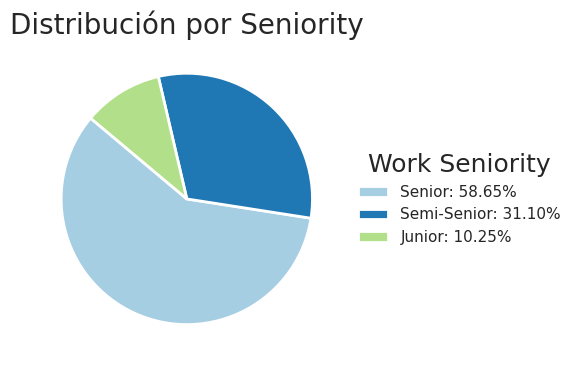

In [42]:
# Visualizacion del dataset limpio y segmentado por seniority

# Agrupacion de datos por seniority
seniority_counts = df_restricted['work_seniority'].value_counts()
labels = seniority_counts.index
values = seniority_counts.values
total = values.sum()

# Seleccion de colores: Matplotlib's colormaps module, Paired palette used
colors = plt.cm.Paired(range(len(labels)))

# Creacion de la figura
fig, ax = plt.subplots(figsize=(8, 4))

# Dibujo del gráfico de torta
wedges, texts = ax.pie(
    values,
    labels=None,    # Sin etiquetas sobre la torta (evita saturar)
    colors=colors,
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Creacion de la tabla lateral + format label: Categoria: (porcentaje)%
legend_labels = [f'{l}: {(v/total)*100:.2f}%' for l, v in zip(labels, values)]

ax.legend(
    wedges,
    legend_labels,
    title="Work Seniority",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1), # Posiciona la leyenda a la derecha
    fontsize=11,
    frameon=False
)

ax.set_title("Distribución por Seniority", fontsize=20)

plt.tight_layout()
plt.show()

## Estudio del dataset con variables numericas

### a) Estudio de la relación salario neto (y) vs años de experiencia (x)

In [44]:
df_restricted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4431 entries, 0 to 4938
Data columns (total 61 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   work_province                                         4431 non-null   object 
 1   work_dedication                                       4431 non-null   object 
 2   work_contract_type                                    4431 non-null   object 
 3   salary_monthly_BRUTO                                  4431 non-null   float64
 4   salary_monthly_NETO                                   4431 non-null   float64
 5   salary_in_usd                                         1361 non-null   object 
 6   salary_last_dollar_value                              901 non-null    object 
 7   salary_has_bonus                                      4431 non-null   object 
 8   salary_bonus_tied_to                                  4431 non-

### b) Estudio de la relación salario neto (y) vs años en la compañia (x).